## Imports

In [1]:
import os
import sys
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate
from sklearn.preprocessing import StandardScaler

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
from utils.tools import (
    extract_clean_segments,
    compute_lagged_correlations,
    find_dominant_lagged_pairs,
    print_dominant_pairs,
    plot_pearson_heatmap,
    report_correlation_distribution,
    classify_anomalies,
    summarize,
    collect_seg_stats,
    plot_threshold_sensitivity,
    compute_univariate_intensity,
    plot_univariate_intensity_distribution
)

## Loading

In [2]:
path = kagglehub.dataset_download("ljolm08/pooled-server-metrics-psm")

print("Path to dataset files:", path)

Path to dataset files: /Users/marcp/.cache/kagglehub/datasets/ljolm08/pooled-server-metrics-psm/versions/1


In [3]:
print("Contents of the dataset directory:", os.listdir(path))
os.listdir(path + "/data")

Contents of the dataset directory: ['data']


['test_label.csv', 'LICENSE', 'test.csv', 'train.csv']

In [4]:
train_df = pd.read_csv(path + "/data/train.csv")
test_df = pd.read_csv(path + "/data/test.csv")
test_label_df = pd.read_csv(path + "/data/test_label.csv")

## Basic infos

In [5]:
train_df.describe()

,timestamp_(min),feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24
count,132481.000000,132481.000000,132481.000000,132481.000000,132481.000000,132279.000000,132232.000000,131918.000000,132434.000000,132434.000000,...,132481.000000,132481.000000,132481.000000,132279.000000,132481.000000,132481.000000,130345.000000,132277.000000,132481.000000,132434.000000
mean,66240.000000,0.835810,0.840205,0.634216,0.575081,0.543310,0.511753,0.549268,0.537706,0.551133,...,0.395703,0.552609,0.626023,0.456716,0.659005,0.009992,0.012716,0.264333,0.106294,0.171198
std,38244.114844,0.067326,0.039472,0.102920,0.049675,0.089438,0.077771,0.064093,0.090120,0.078996,...,0.040340,0.078733,0.050332,0.100087,0.033860,0.010383,0.015244,0.095716,0.125078,0.070909
min,0.000000,0.486490,0.525682,0.421484,0.380874,0.065106,0.110161,0.215909,0.077795,0.038693,...,0.126150,0.096146,0.459456,0.148545,0.502730,0.000000,0.000000,0.118326,0.000000,0.009217
25%,33120.000000,0.789497,0.820488,0.580170,0.543702,0.471135,0.451409,0.505682,0.470921,0.490750,...,0.366614,0.491537,0.585286,0.390680,0.638411,0.001686,0.000000,0.197355,0.017429,0.115207
50%,66240.000000,0.837290,0.843873,0.603304,0.572077,0.548428,0.507439,0.539773,0.529834,0.552253,...,0.393919,0.554260,0.613736,0.431563,0.652471,0.006745,0.007117,0.222880,0.047930,0.165899
75%,99360.000000,0.880603,0.866423,0.625805,0.611127,0.604875,0.559671,0.579545,0.588369,0.603570,...,0.424146,0.605177,0.659356,0.478530,0.670762,0.015177,0.024911,0.327563,0.165577,0.221198
max,132480.000000,1.000000,0.909956,1.000000,0.676682,0.929442,0.877493,1.000000,0.968278,0.935128,...,1.000000,0.934433,0.919789,1.000000,1.000000,1.000000,0.270463,1.000000,1.000000,1.000000


## Data exploration

In [6]:
# Check if there is any missing values in the training data
train_df.isnull().sum()

timestamp_(min)       0
feature_0             0
feature_1             0
feature_2             0
feature_3             0
feature_4           202
feature_5           249
feature_6           563
feature_7            47
feature_8            47
feature_9             0
feature_10           47
feature_11            0
feature_12            0
feature_13          249
feature_14          202
feature_15            0
feature_16            0
feature_17            0
feature_18          202
feature_19            0
feature_20            0
feature_21         2136
feature_22          204
feature_23            0
feature_24           47
dtype: int64

In [7]:
# Check if timestep is constant
timestep_diffs = train_df['timestamp_(min)'].diff().dropna()
print("Unique timestep differences:", timestep_diffs.unique())

Unique timestep differences: [1.]


In [8]:
print(train_df.describe().loc[['mean', 'std', 'min', 'max']])

      timestamp_(min)  feature_0  feature_1  feature_2  feature_3  feature_4  \
mean     66240.000000   0.835810   0.840205   0.634216   0.575081   0.543310   
std      38244.114844   0.067326   0.039472   0.102920   0.049675   0.089438   
min          0.000000   0.486490   0.525682   0.421484   0.380874   0.065106   
max     132480.000000   1.000000   0.909956   1.000000   0.676682   0.929442   

      feature_5  feature_6  feature_7  feature_8  ...  feature_15  feature_16  \
mean   0.511753   0.549268   0.537706   0.551133  ...    0.395703    0.552609   
std    0.077771   0.064093   0.090120   0.078996  ...    0.040340    0.078733   
min    0.110161   0.215909   0.077795   0.038693  ...    0.126150    0.096146   
max    0.877493   1.000000   0.968278   0.935128  ...    1.000000    0.934433   

      feature_17  feature_18  feature_19  feature_20  feature_21  feature_22  \
mean    0.626023    0.456716    0.659005    0.009992    0.012716    0.264333   
std     0.050332    0.100087    0

In [9]:
# Count number of entries for train, test, test labels
print("Number of training entries:", len(train_df))
print("Number of training entries:", len(train_df.dropna()))
print("Number of testing entries:", len(test_df))
print("Number of testing labels entries:", len(test_label_df))

Number of training entries: 132481
Number of training entries: 129784
Number of testing entries: 87841
Number of testing labels entries: 87841


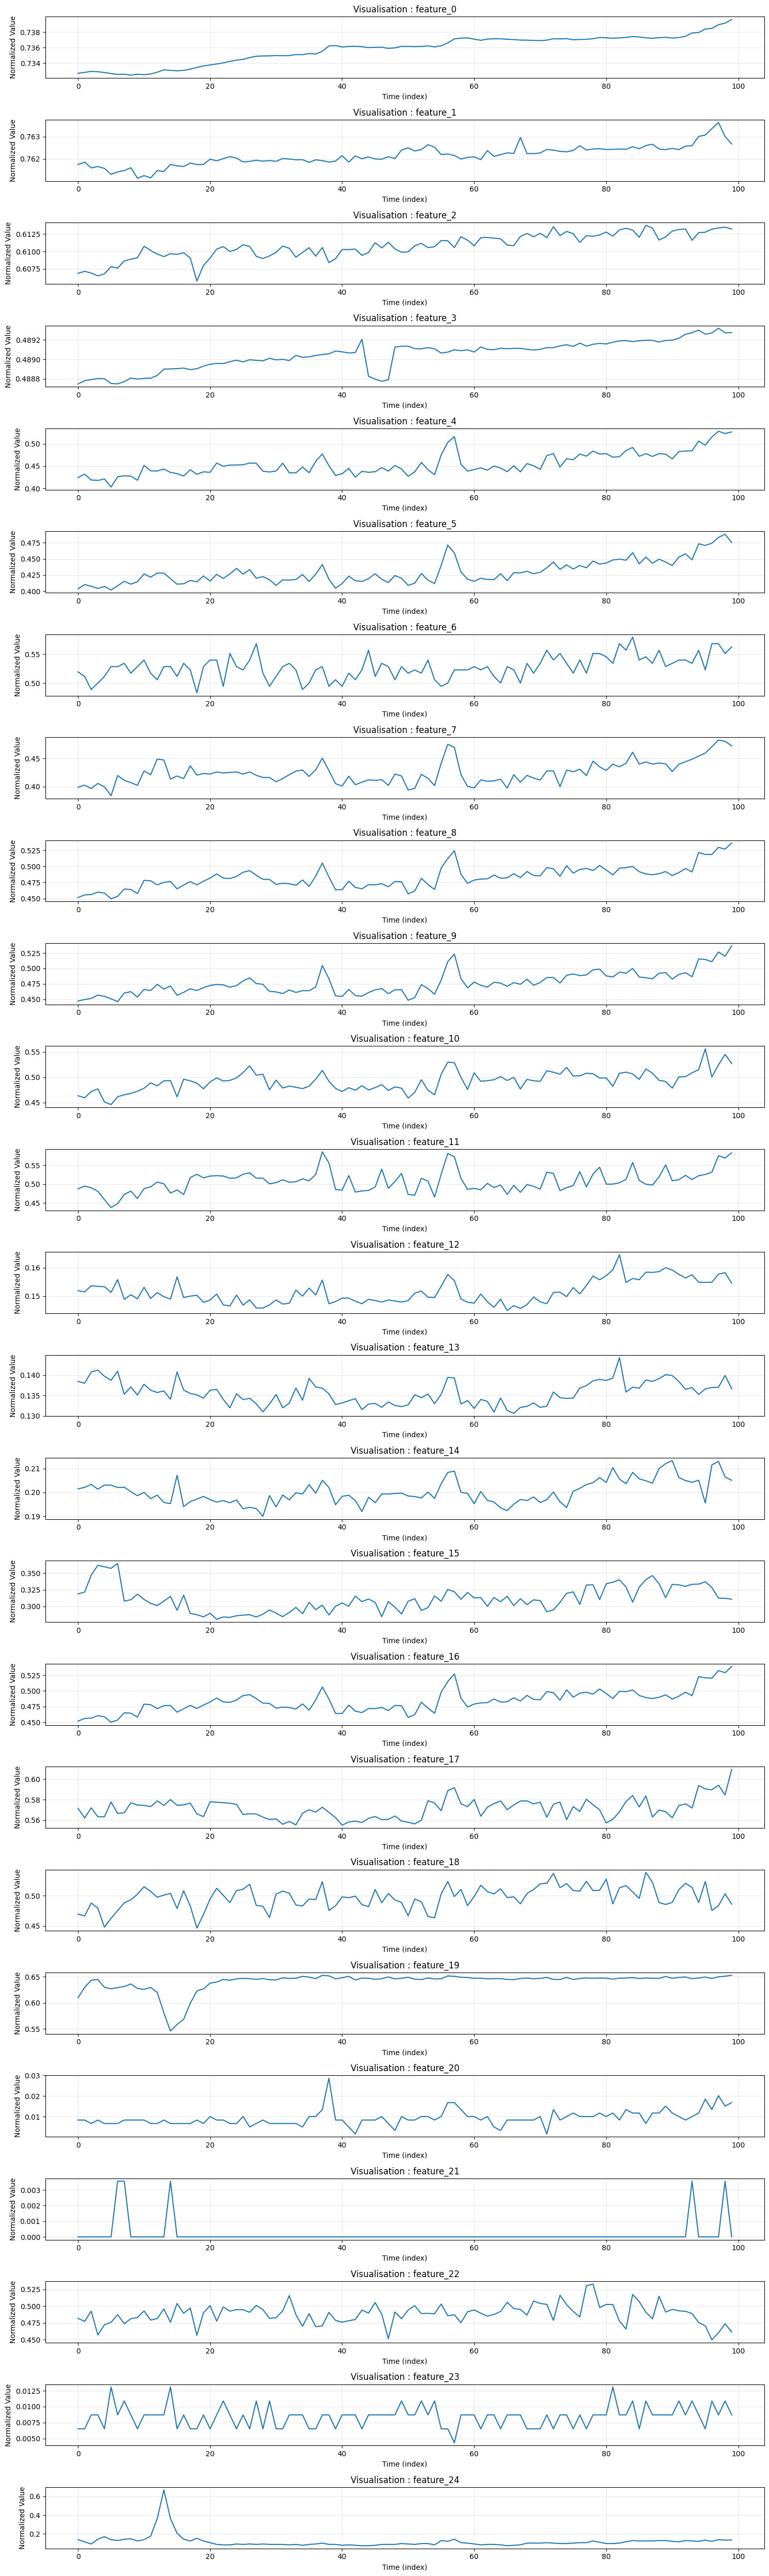

In [10]:
features_to_plot = [f for f in train_df.columns if "timestamp" not in f.lower()]
num_features = len(features_to_plot)

plt.figure(figsize=(15, num_features * 2))

for i, feature in enumerate(features_to_plot):
    plt.subplot(num_features, 1, i + 1)
    plt.plot(train_df[feature][:100])
    
    plt.title(f"Visualisation : {feature}")
    plt.xlabel('Time (index)')
    plt.ylabel('Normalized Value')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Correlation Analysis on normal data

Total: 132481, clean: 129784, lines removed (NaN): 2697


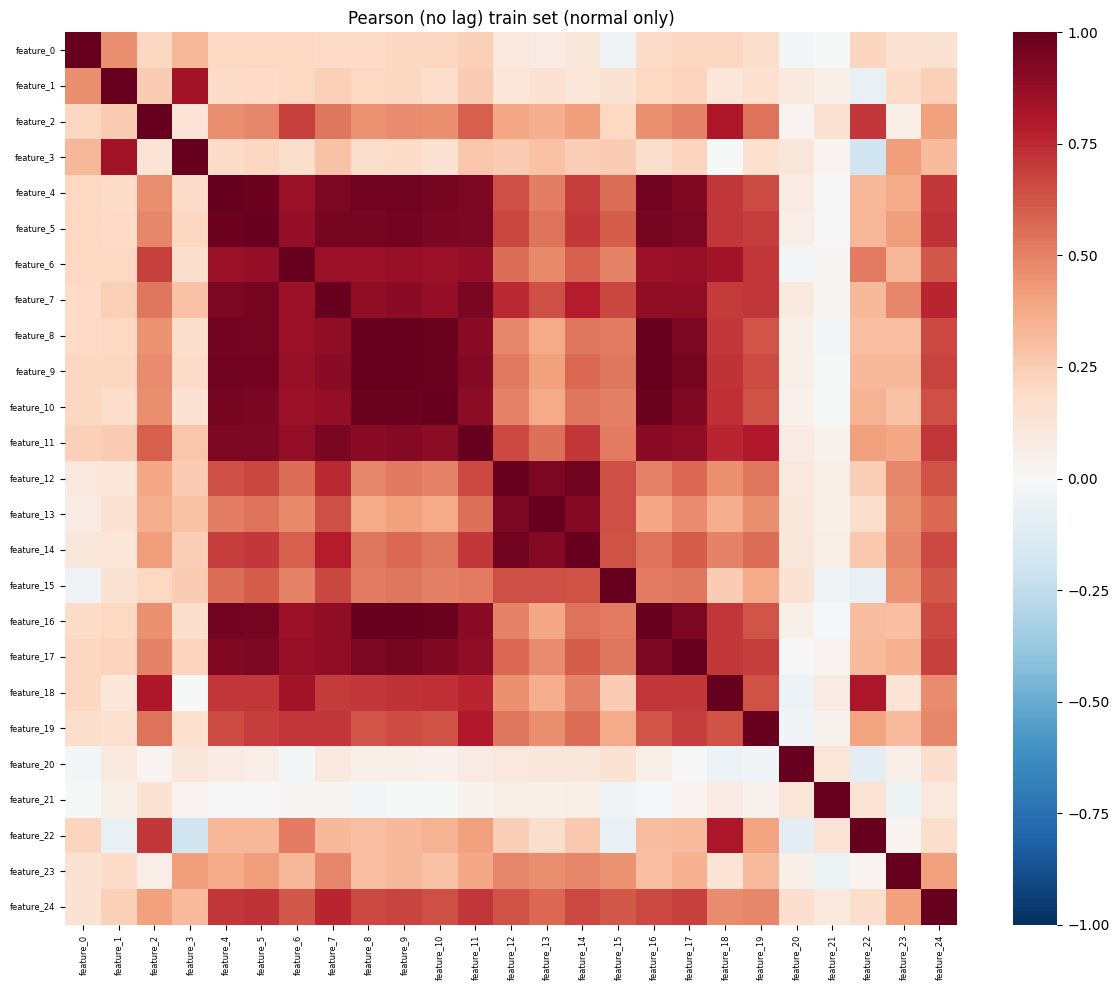

In [11]:
train_full = train_df.drop(columns=['timestamp_(min)'])
features = train_full.columns.tolist()

mask_clean = ~train_full.isnull().any(axis=1)
train_clean = train_full[mask_clean]
print(f"Total: {len(train_full)}, clean: {len(train_clean)}, lines removed (NaN): {(~mask_clean).sum()}")

pearson_matrix = train_clean.corr(method='pearson').values
plot_pearson_heatmap(pearson_matrix, features, title="Pearson (no lag) train set (normal only)", figsize=(12, 10))

In [12]:
print("Distribution of |r| (off-diagonal):")
report_correlation_distribution(pearson_matrix)

Distribution of |r| (off-diagonal):
Total pairs: 300
  Pairs with |r| > 0.3: 183/300 (61.0%)
  Pairs with |r| > 0.5: 127/300 (42.3%)
  Pairs with |r| > 0.7: 72/300 (24.0%)


In [13]:
max_lag = 192  # CrossAD uses 192 (vs 128 for GECCO)

features_array = train_full.values
segments = extract_clean_segments(features_array, mask_clean.values, max_lag=max_lag)
if not segments:
    raise ValueError(f"No clean segment with length >= {2 * max_lag}.")

seg_lengths = list(map(len, segments))
print(f"Segments (L >= {2 * max_lag}): {len(segments)} | min={min(seg_lengths)}, max={max(seg_lengths)}, total={sum(seg_lengths)}")

Segments (L >= 384): 6 | min=1307, max=50556, total=129784


In [14]:
lagged_corrs = compute_lagged_correlations(segments, max_lag=max_lag)

Segments (Spearman): 100%|██████████| 6/6 [00:01<00:00,  3.54it/s]


In [15]:
pairs_info = find_dominant_lagged_pairs(lagged_corrs, max_lag=max_lag, threshold=0.5)
print("Pairs with dominant lagged correlation (|r(best_lag)| > 0.5 and > |r(0)|:")
print_dominant_pairs(pairs_info, feature_names=features)

Pairs with dominant lagged correlation (|r(best_lag)| > 0.5 and > |r(0)|:
Total pairs: 164
 feature_1 - feature_3 : r(0)=+0.851  r(-69)=+0.870  [pearson]
 feature_2 - feature_18: r(0)=+0.691  r(-60)=+0.696  [pearson]
 feature_5 - feature_15: r(0)=+0.531  r(+156)=+0.609  [spearman]
 feature_7 - feature_15: r(0)=+0.550  r(+156)=+0.601  [spearman]
 feature_4 - feature_15: r(0)=+0.477  r(+177)=+0.598  [spearman]
feature_15 - feature_17: r(0)=+0.470  r(-142)=+0.567  [spearman]
 feature_9 - feature_15: r(0)=+0.459  r(+155)=+0.561  [spearman]
feature_10 - feature_15: r(0)=+0.457  r(+142)=+0.560  [spearman]
feature_15 - feature_16: r(0)=+0.451  r(-142)=+0.554  [spearman]
 feature_8 - feature_15: r(0)=+0.449  r(+142)=+0.554  [spearman]
feature_14 - feature_15: r(0)=+0.541  r(+160)=+0.553  [spearman]
 feature_2 - feature_22: r(0)=+0.539  r(-75)=+0.550  [pearson]
feature_15 - feature_24: r(0)=+0.535  r(-89)=+0.538  [spearman]
feature_10 - feature_14: r(0)=+0.527  r(-20)=+0.531  [spearman]
 featur

## Anomaly Analysis

In [16]:
X_train_full = train_df.drop(columns=['timestamp_(min)']).values.astype(np.float64)
X_test_full = test_df.drop(columns=['timestamp_(min)']).values.astype(np.float64)
ev = test_label_df.iloc[:, -1].values.astype(int)

mask_tr = ~np.isnan(X_train_full).any(axis=1)
scaler = StandardScaler().fit(X_train_full[mask_tr])
X = scaler.transform(X_test_full)
N, C = X.shape

In [17]:
n_train = len(X_train_full)
n_test = len(ev)
n_anom = int(ev.sum())
dim = X.shape[1]

print(f"Dimension: {dim}")
print(f"Train Size: {n_train}")
print(f"Test (labeled): {n_test}")
print(f"Anomaly Ratio (%): {100.0 * n_anom / n_test:.2f}")

Dimension: 25
Train Size: 132481
Test (labeled): 87841
Anomaly Ratio (%): 27.76


In [18]:
df_long, df_short = classify_anomalies(X, ev, pairs_info=pairs_info)

display_cols = ['seg', 'start', 'end', 'len', 'n_dev']
for m in ['pearson', 'spearman', 'dcor']:
    display_cols += [f'd_{m}', f'lab_{m}']
print(tabulate(df_long[display_cols], headers='keys', tablefmt='psql', floatfmt='.3f', showindex=False, missingval='-'))

summarize(df_long, df_short)

+-------+---------+-------+-------+---------+-------------+---------------+--------------+----------------+----------+------------+
|   seg |   start |   end |   len |   n_dev |   d_pearson | lab_pearson   |   d_spearman | lab_spearman   |   d_dcor | lab_dcor   |
|-------+---------+-------+-------+---------+-------------+---------------+--------------+----------------+----------+------------|
|     3 |    3248 |  3439 |   191 |      23 |       1.420 | BOTH          |        1.511 | BOTH           |    0.752 | BOTH       |
|     6 |    4875 |  5156 |   281 |      24 |       1.313 | BOTH          |        1.497 | BOTH           |    0.717 | BOTH       |
|     9 |    7062 |  7393 |   331 |      22 |       1.535 | BOTH          |        1.542 | BOTH           |    0.972 | BOTH       |
|    11 |    7799 |  8149 |   350 |      23 |       1.300 | BOTH          |        1.384 | BOTH           |    0.756 | BOTH       |
|    13 |   10452 | 10464 |    12 |      11 |       1.421 | BOTH          | 

In [19]:
# segment size min vs size max
min_len = df_long['len'].min()
max_len = df_long['len'].max()
print(f"Segment length: min={min_len}, max={max_len}")

Segment length: min=10, max=8861


Actually, we don't mind about the 4/37 undetected as they're < 10 and thus it's impossible to estimate a proper correlation on such a small number of samples. 

Also, we note that even segments just above the minimum length threshold (>10), where correlation estimation remains noisy, are systematically classified as BOTH or UNIVARIATE, never CROSS-CHANNEL exclusively. This suggests that the absence of correlation-only anomalies is not an artifact of the minimum length cutoff.

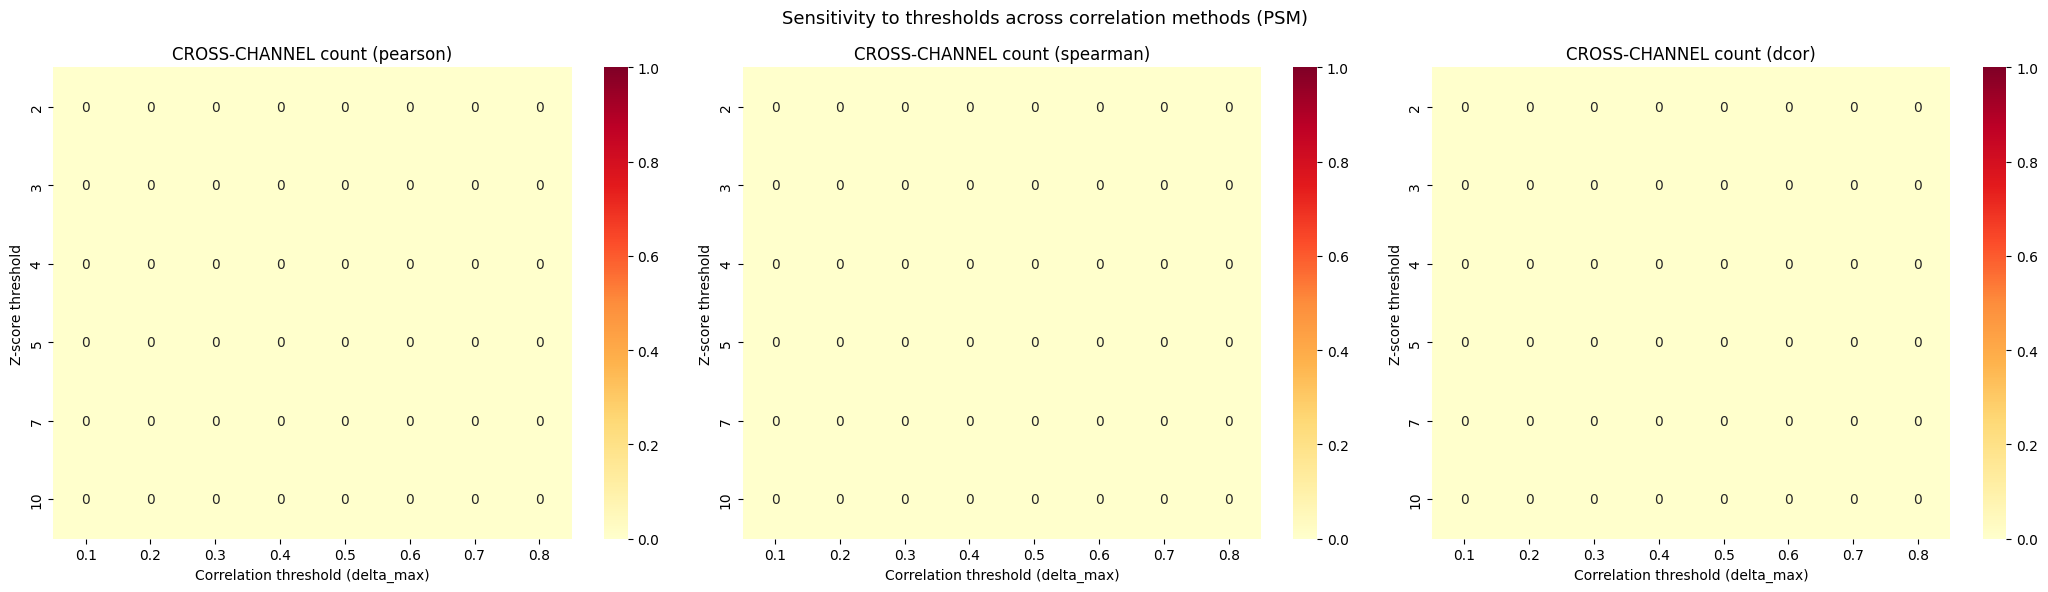

{'pearson': array([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]]),
 'spearman': array([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]]),
 'dcor': array([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]])}

In [20]:
seg_stats = collect_seg_stats(X, ev, pairs_info=pairs_info)
plot_threshold_sensitivity(seg_stats, title="Sensitivity to thresholds across correlation methods (PSM)")

In [21]:
intensity_df, summary = compute_univariate_intensity(
    test_arrays=[X], label_arrays=[ev], names=['psm'],
)
print(tabulate(summary, headers='keys', tablefmt='psql', floatfmt='.3f', showindex=False))

+--------------+------------------+--------------------+-----------------+
|   n_segments |   mean_ratio_uni |   median_ratio_uni |   min_ratio_uni |
|--------------+------------------+--------------------+-----------------|
|       34.000 |            0.914 |              0.964 |           0.364 |
+--------------+------------------+--------------------+-----------------+


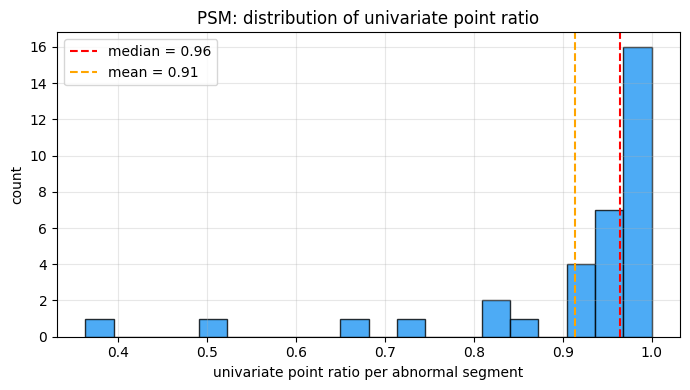

In [22]:
plot_univariate_intensity_distribution(intensity_df, 'PSM')

Number of BOTH segments (union over pearson/spearman/dcor): 34
Anomalous points retained: 24292 / 24381 (99.6%)
+--------------+------------------+--------------------+-----------------+
|   n_segments |   mean_ratio_uni |   median_ratio_uni |   min_ratio_uni |
|--------------+------------------+--------------------+-----------------|
|       34.000 |            0.911 |              0.964 |           0.364 |
+--------------+------------------+--------------------+-----------------+


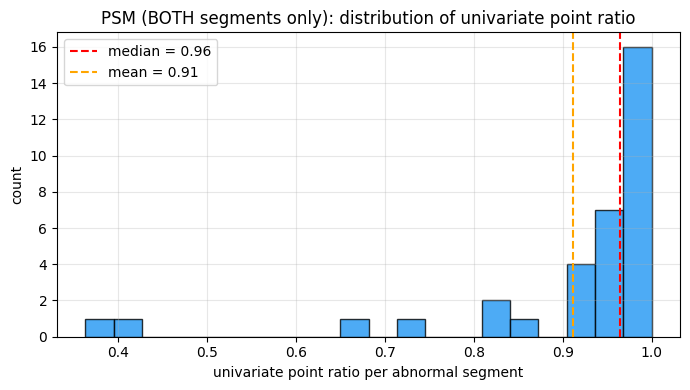

In [23]:
both_mask = (
    (df_long['lab_pearson'] == 'BOTH') |
    (df_long['lab_spearman'] == 'BOTH') |
    (df_long['lab_dcor'] == 'BOTH')
)
both_segments = df_long.loc[both_mask, ['start', 'end']].astype(int).values

ev_both = np.zeros_like(ev)
for s, e in both_segments:
    ev_both[s:e] = 1

print(f"Number of BOTH segments (union over pearson/spearman/dcor): {len(both_segments)}")
print(f"Anomalous points retained: {int(ev_both.sum())} / {int(ev.sum())} ({100.0 * ev_both.sum() / max(ev.sum(), 1):.1f}%)")

intensity_df_both, summary_both = compute_univariate_intensity(
    test_arrays=[X], label_arrays=[ev_both], names=['psm_both'],
)
print(tabulate(summary_both, headers='keys', tablefmt='psql', floatfmt='.3f', showindex=False))

plot_univariate_intensity_distribution(intensity_df_both, 'PSM (BOTH segments only)')